We will NOT predict individual flight delay.

Instead, we will predict:

Whether a carrier-airport pair will experience HIGH delay rate in a given month.

In [2]:
import pandas as pd
import numpy as np

# Load dataset
file_path = "Airline_Delay_Cause.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [3]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData types:")
print(df.dtypes)


Dataset shape: (171666, 21)

Columns:
Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

Data types:
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              floa

In [4]:
# Check missing values
null_counts = df.isnull().sum()

print("Missing values per column:")
print(null_counts[null_counts > 0])


Missing values per column:
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


In [5]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [6]:
df[df["arr_flights"].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3880,2023,6,MQ,Envoy Air,CLL,"College Station/Bryan, TX: Easterwood Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,2023,6,MQ,Envoy Air,EUG,"Eugene, OR: Mahlon Sweet Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,2023,6,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3904,2023,6,MQ,Envoy Air,GRB,"Green Bay, WI: Green Bay Austin Straubel Inter...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,2023,6,MQ,Envoy Air,HPN,"White Plains, NY: Westchester County",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df[df["arr_flights"].isnull()].shape

(240, 21)

In [8]:
df = df.dropna(subset=["arr_flights"])

In [9]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights              0
arr_del15              203
carrier_ct               0
weather_ct               0
nas_ct                   0
security_ct              0
late_aircraft_ct         0
arr_cancelled            0
arr_diverted             0
arr_delay                0
carrier_delay            0
weather_delay            0
nas_delay                0
security_delay           0
late_aircraft_delay      0
dtype: int64

In [10]:
df[df["arr_del15"].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
16907,2022,10,OO,SkyWest Airlines Inc.,PHL,"Philadelphia, PA: Philadelphia International",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17282,2022,10,YV,Mesa Airlines Inc.,JAN,"Jackson/Vicksburg, MS: Jackson Medgar Wiley Ev...",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27527,2022,4,YV,Mesa Airlines Inc.,MLB,"Melbourne, FL: Melbourne International",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27554,2022,4,YV,Mesa Airlines Inc.,SHV,"Shreveport, LA: Shreveport Regional",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32066,2022,1,OO,SkyWest Airlines Inc.,BOS,"Boston, MA: Logan International",7.0,NaN,0.0,0.0,...,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df[df["arr_del15"].isnull()][["arr_flights", "arr_cancelled"]].describe()

,arr_flights,arr_cancelled
count,203.000000,203.000000
mean,9.995074,9.901478
std,17.820751,17.835334
min,1.000000,0.000000
25%,1.000000,1.000000
50%,5.000000,5.000000
75%,10.000000,10.000000
max,120.000000,120.000000


In [12]:
df[df["arr_del15"].isnull()]["arr_flights"].unique()

array([  1.,   7.,   2.,   4., 120.,  28.,  18.,   9.,   8.,   5.,  17.,
        10.,  20.,  13., 112.,  15.,  23.,  11.,  29.,   3.,   6.,  31.,
        12.,  34.,  16.,  21.,  32.,  14.,  19.,  45.,  27.,  71.,  30.,
        94.,  56., 106.,  77.,  22.])

In [13]:
df = df.dropna(subset=["arr_del15"])
df.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

Rows with undefined arrival delay counts were removed, as they corresponded to months where flights were cancelled and no arrival performance could be evaluated.

In [14]:
df.shape

(171223, 21)

### Target Engineering

In [15]:
df["delay_rate"] = df["arr_del15"] / df["arr_flights"]
df["delay_rate"].describe()

count    171223.000000
mean          0.183365
std           0.110349
min           0.000000
25%           0.109890
50%           0.170732
75%           0.241528
max           1.000000
Name: delay_rate, dtype: float64

<Axes: >

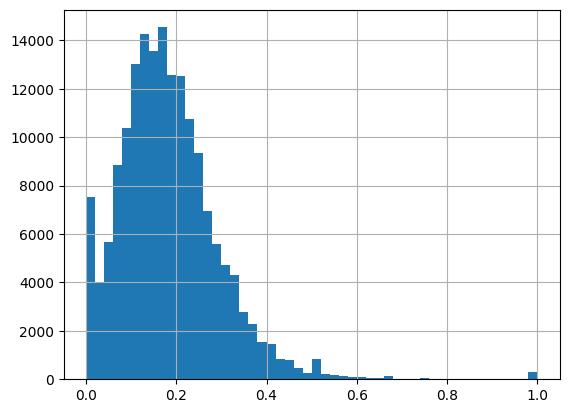

In [16]:
df["delay_rate"].hist(bins=50)

In [17]:
df["delay_rate"].quantile([0.25, 0.5, 0.75])

0.25    0.109890
0.50    0.170732
0.75    0.241528
Name: delay_rate, dtype: float64

In [18]:
df["high_delay"] = (df["delay_rate"] >= 0.25).astype(int)

In [19]:
df["high_delay"].value_counts(normalize=True)

high_delay
0    0.767397
1    0.232603
Name: proportion, dtype: float64

In [20]:
df = df[df["arr_flights"] >= 20]
df.shape
df["delay_rate"].describe()

count    155952.000000
mean          0.183724
std           0.096153
min           0.000000
25%           0.114711
50%           0.172799
75%           0.239766
max           0.903226
Name: delay_rate, dtype: float64

In [21]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["log_arr_flights"] = np.log1p(df["arr_flights"])

df["cancel_rate"] = df["arr_cancelled"] / df["arr_flights"]
df["divert_rate"] = df["arr_diverted"] / df["arr_flights"]


In [22]:
print(df.head())
df.shape

   year  month carrier       carrier_name airport  \
0  2023      8      9E  Endeavor Air Inc.     ABE   
1  2023      8      9E  Endeavor Air Inc.     ABY   
2  2023      8      9E  Endeavor Air Inc.     AEX   
3  2023      8      9E  Endeavor Air Inc.     AGS   
4  2023      8      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         89.0       13.0   
1             Albany, GA: Southwest Georgia Regional         62.0       10.0   
2           Alexandria, LA: Alexandria International         62.0       10.0   
3        Augusta, GA: Augusta Regional at Bush Field         66.0       12.0   
4                   Albany, NY: Albany International         92.0       22.0   

   carrier_ct  weather_ct  ...  nas_delay  security_delay  \
0        2.25        1.60  ...      118.0             0.0   
1        1.97        0.04  ...       62.0             0.0   
2        2.73    

(155952, 28)

In [23]:
leakage_cols = [
    "arr_del15",
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
    "arr_delay",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

df = df.drop(columns=leakage_cols)


In [24]:
df = df.drop(columns=["carrier_name", "airport_name", "arr_flights", "arr_cancelled", "arr_diverted", "month"])
print(df.head())

   year carrier airport  delay_rate  high_delay  month_sin  month_cos  \
0  2023      9E     ABE    0.146067           0  -0.866025       -0.5   
1  2023      9E     ABY    0.161290           0  -0.866025       -0.5   
2  2023      9E     AEX    0.161290           0  -0.866025       -0.5   
3  2023      9E     AGS    0.181818           0  -0.866025       -0.5   
4  2023      9E     ALB    0.239130           0  -0.866025       -0.5   

   log_arr_flights  cancel_rate  divert_rate  
0         4.499810     0.022472     0.011236  
1         4.143135     0.000000     0.016129  
2         4.143135     0.016129     0.000000  
3         4.204693     0.015152     0.015152  
4         4.532599     0.021739     0.000000  


In [25]:
df = df.drop(columns=["delay_rate"]) ## Target variable is "high_delay", so we drop "delay_rate" to avoid leakage.
df.head()


,year,carrier,airport,high_delay,month_sin,month_cos,log_arr_flights,cancel_rate,divert_rate
0,2023,9E,ABE,0,-0.866025,-0.5,4.499810,0.022472,0.011236
1,2023,9E,ABY,0,-0.866025,-0.5,4.143135,0.000000,0.016129
2,2023,9E,AEX,0,-0.866025,-0.5,4.143135,0.016129,0.000000
3,2023,9E,AGS,0,-0.866025,-0.5,4.204693,0.015152,0.015152
4,2023,9E,ALB,0,-0.866025,-0.5,4.532599,0.021739,0.000000


In [26]:
X = df.drop(columns=["high_delay"])
y = df["high_delay"]

In [27]:
df["year"].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013])

In [28]:
### Time Based Split
train = df[df["year"] < 2023]
test = df[df["year"] == 2023]

X_train = train.drop(columns=["high_delay"])
y_train = train["high_delay"]

X_test = test.drop(columns=["high_delay"])
y_test = test["high_delay"]


In [29]:
X_train = X_train.drop(columns=["year"])
X_test = X_test.drop(columns=["year"])


### Logistic Regression

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = ["carrier", "airport"]
numeric_cols = X_train.drop(columns=categorical_cols).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])


In [31]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.81      0.65      0.72      7184
           1       0.55      0.74      0.63      4104

    accuracy                           0.68     11288
   macro avg       0.68      0.69      0.67     11288
weighted avg       0.72      0.68      0.69     11288

ROC-AUC: 0.7451895551409456


### Random Forest Model

In [33]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


              precision    recall  f1-score   support

           0       0.73      0.90      0.80      7184
           1       0.70      0.42      0.52      4104

    accuracy                           0.72     11288
   macro avg       0.71      0.66      0.66     11288
weighted avg       0.72      0.72      0.70     11288

ROC-AUC: 0.7679059140791535


In [34]:
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

y_pred_adj = (y_prob_rf >= 0.35).astype(int)

print(classification_report(y_test, y_pred_adj))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.78      0.77      0.77      7184
           1       0.61      0.61      0.61      4104

    accuracy                           0.71     11288
   macro avg       0.69      0.69      0.69     11288
weighted avg       0.71      0.71      0.71     11288

ROC-AUC: 0.7679059140791535


Logistic regression achieved higher recall for high-delay months, while Random Forest achieved higher ROC-AUC and precision.
This demonstrates the trade-off between sensitivity and specificity in operational delay prediction.

In [35]:
import pandas as pd

feature_names = (
    numeric_cols.tolist() +
    list(model_rf.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(["carrier", "airport"]))
)

importances = model_rf.named_steps["classifier"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)


,feature,importance
3,cancel_rate,0.145072
2,log_arr_flights,0.135109
1,month_cos,0.070324
0,month_sin,0.063174
4,divert_rate,0.046491
9,carrier_DL,0.027952
11,carrier_F9,0.013819
8,carrier_B6,0.012033
5,carrier_9E,0.011217
18,carrier_OO,0.007795


🏆 Top Predictors of High Delay
1️⃣ cancel_rate (0.145)

This is the strongest signal.

Interpretation:

Months with higher cancellation rates are strongly associated with high delay rates.

Operational instability clusters together.

This makes real-world sense:

When operations break down, cancellations and delays rise together.

2️⃣ log_arr_flights (0.135)

Airport volume matters a lot.

Interpretation:

Larger airports (higher traffic) are more prone to high delay months.

Congestion effect.

This is a strong operational insight.

3️⃣ Seasonality (month_cos, month_sin)

Combined importance ≈ 0.13

Interpretation:

Time of year significantly affects delays.

Likely winter storms + summer congestion.

This confirms your cyclical encoding was a good decision.

4️⃣ divert_rate (0.046)

Diversions also correlate with high delay.

Again:

Operational stress events cluster.

5️⃣ Carrier Effects

We see:

DL (Delta)

F9 (Frontier)

B6 (JetBlue)

9E (Endeavor)

OO (SkyWest)

WN (Southwest)

These features represent airline-specific behavior.

Important note:
Their individual importance is smaller than operational metrics.

Meaning:

Operational conditions matter more than airline identity.

That’s a powerful insight.

### Model Comparison Visualizations

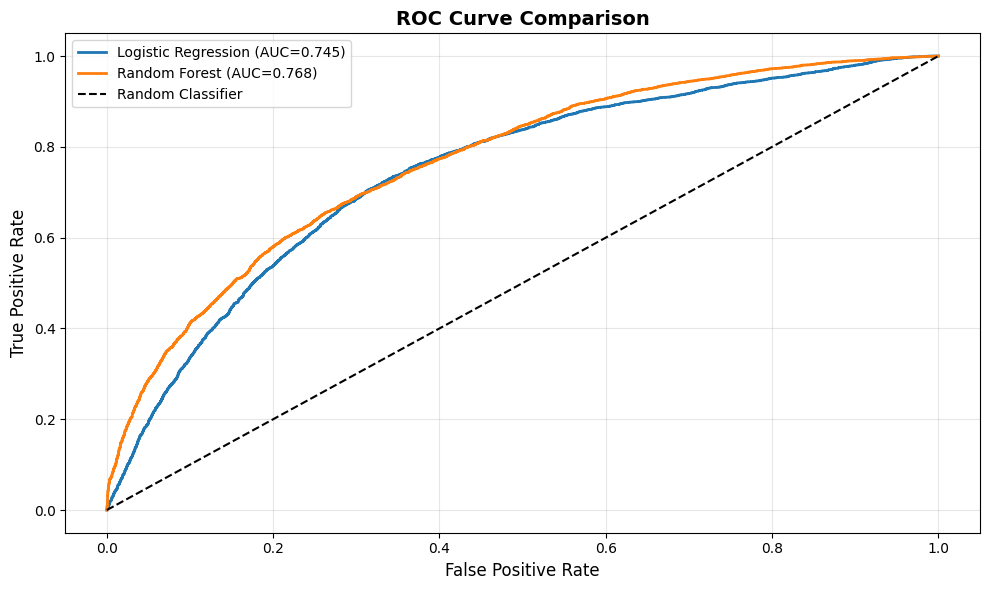

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

# 1. ROC Curves Comparison
plt.figure(figsize=(10, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This is an ROC curve comparison for two classifiers. It shows the tradeoff between True Positive Rate (y-axis) and False Positive Rate (x-axis) across all thresholds. The dashed diagonal is random guessing; curves above it are better. The legend shows AUC (area under the curve): Logistic Regression has AUC ≈ 0.745 and Random Forest has AUC ≈ 0.768, so Random Forest performs slightly better overall.

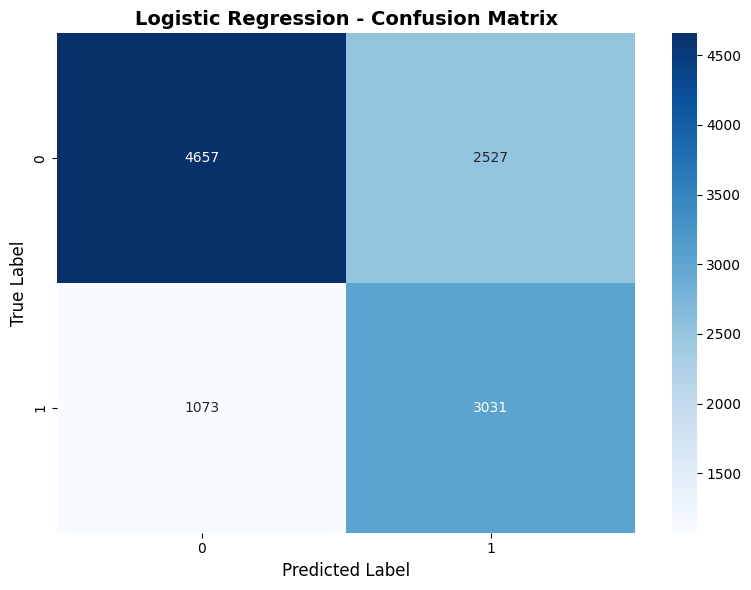

In [37]:
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

This is the confusion matrix for your logistic regression classifier (rows = true label, columns = predicted label):

True negatives (0 predicted as 0): 4657
False positives (0 predicted as 1): 2527
False negatives (1 predicted as 0): 1073
True positives (1 predicted as 1): 3031
So it correctly identifies many positives (recall is fairly high), but it also flags a lot of negatives as positive (false positives). Approx metrics:

Accuracy ≈ 0.681
Precision (for class 1) ≈ 0.546
Recall (for class 1) ≈ 0.739
F1 ≈ 0.626

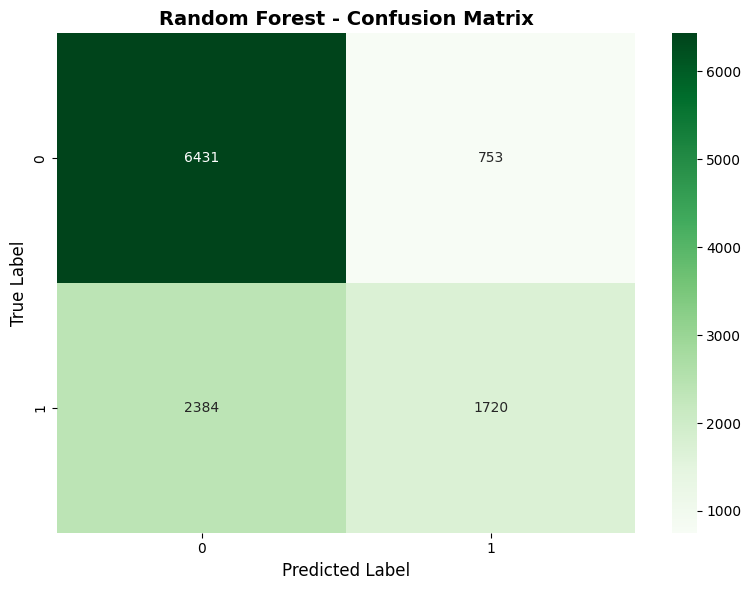

In [38]:
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

This is the Random Forest confusion matrix (rows = true label, columns = predicted label):

True negatives: 6431
False positives: 753
False negatives: 2384
True positives: 1720
So it’s much better at identifying class 0 (few false positives), but it misses a lot of class 1 cases (low recall). Approx metrics:

Accuracy ≈ 0.722
Precision (class 1) ≈ 0.696
Recall (class 1) ≈ 0.419
F1 ≈ 0.523
Compared to Logistic Regression, this model is more conservative about predicting class 1.

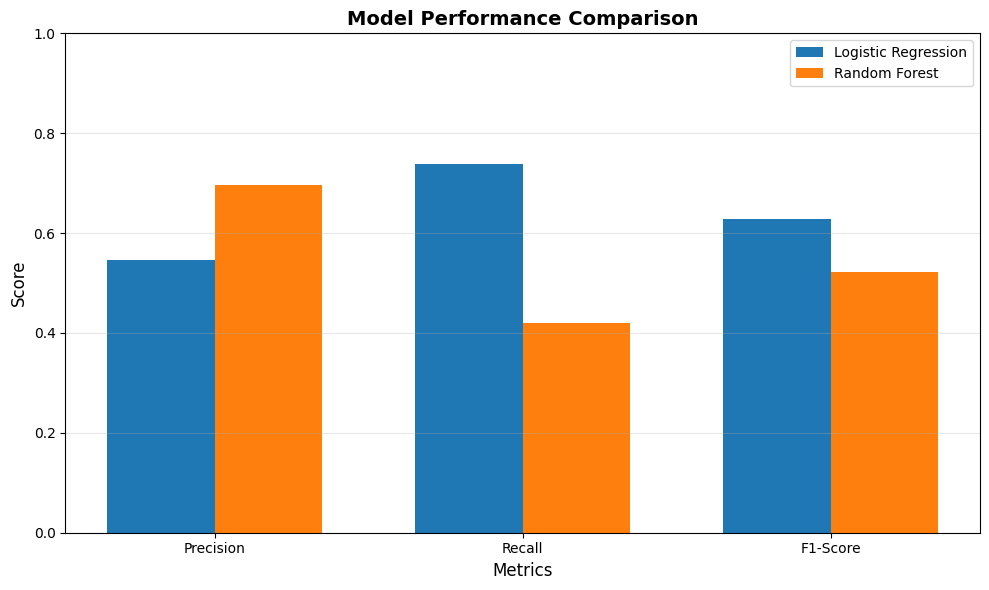

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = ['Precision', 'Recall', 'F1-Score']
lr_scores = [
    precision_score(y_test, model.predict(X_test)),
    recall_score(y_test, model.predict(X_test)),
    f1_score(y_test, model.predict(X_test))
]
rf_scores = [
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, metrics)
plt.legend(fontsize=10)
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

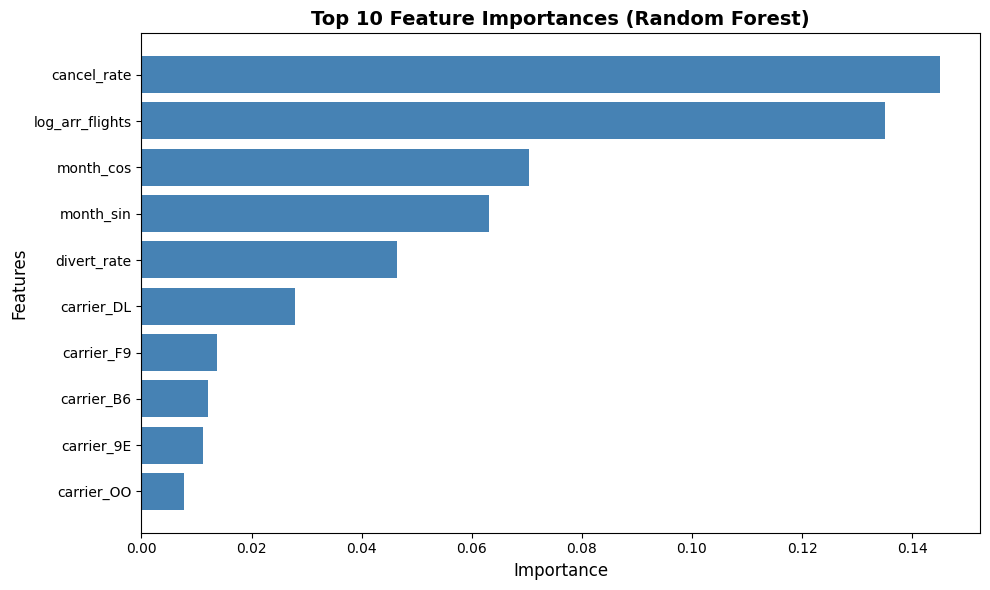

In [40]:
plt.figure(figsize=(10, 6))
feat_imp_top10 = feat_imp.head(10)
plt.barh(feat_imp_top10['feature'], feat_imp_top10['importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

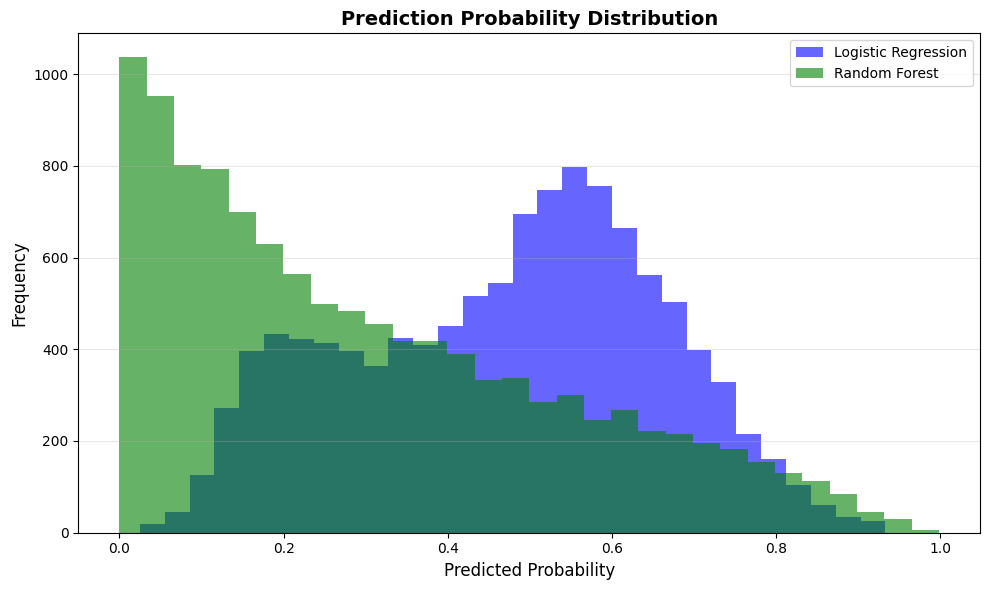

In [41]:
plt.figure(figsize=(10, 6))
plt.hist(model.predict_proba(X_test)[:, 1], bins=30, alpha=0.6, label='Logistic Regression', color='blue')
plt.hist(y_prob_rf, bins=30, alpha=0.6, label='Random Forest', color='green')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Logistic Regression (Blue):

Centered around 0.45-0.65 probability
Smooth, bell-curve distribution
Gives moderate, spread-out confidence levels across the range
More balanced predictions

Random Forest (Green):

Heavily skewed left with a huge peak near 0.0
Very few predictions above 0.7
Extremely confident it's predicting "no delay" (class 0)
Rarely confident about delays
What this means:

Random Forest is overly conservative — it almost always predicts low delay probability, which explains why it has:

High precision (when it says delay, it's right)
Low recall (but it barely predicts delays at all)
Logistic Regression is more balanced — it spreads its confidence across the probability range, giving it better recall and F1-score.

In [42]:
df.describe()

,year,high_delay,month_sin,month_cos,log_arr_flights,cancel_rate,divert_rate
count,155952.000000,155952.000000,1.559520e+05,1.559520e+05,155952.000000,155952.000000,155952.000000
mean,2018.490561,0.225460,-7.477393e-03,-6.939610e-03,4.979680,0.022954,0.002797
std,2.909982,0.417886,7.087690e-01,7.053714e-01,1.222348,0.053306,0.008489
min,2013.000000,0.000000,-1.000000e+00,-1.000000e+00,3.044522,0.000000,0.000000
25%,2016.000000,0.000000,-8.660254e-01,-5.000000e-01,4.110874,0.000000,0.000000
50%,2019.000000,0.000000,-2.449294e-16,-1.836970e-16,4.770685,0.006658,0.000000
75%,2021.000000,0.000000,5.000000e-01,5.000000e-01,5.638355,0.025641,0.001649
max,2023.000000,1.000000,1.000000e+00,1.000000e+00,9.997797,0.988095,0.609195


Logistic Regression is better at:

Recall (~0.74): Catching actual delayed flights. If you need to identify most/all flights that will be delayed, this is your model.
F1-Score (~0.63): Overall balanced performance.

Random Forest is better at:

Precision (~0.70): Being confident in its predictions. When it says a flight will be delayed, it's usually correct. Better if false alarms are costly.

For flight delay prediction scenarios:

Choose Logistic Regression if missing delayed flights is expensive (e.g., crew scheduling, resources prep)
Choose Random Forest if false alarms are expensive (e.g., unnecessary passenger notifications, operational disruption)
Logistic Regression is the more practical choice here since it has better overall performance (higher F1 and recall), making it more useful for catching delays.

## Delay Prediction Function

In [43]:
def predict_delay(month, carrier, airport, cancel_rate=0.02, divert_rate=0.005, arr_flights=100, model_type='logistic'):
    """
    Predict if a carrier-airport pair will experience HIGH delay rate in a given month.
    
    Parameters:
    -----------
    month : int (1-12)
        Month of the year
    carrier : str
        Carrier code (e.g., 'AA', 'DL', 'UA')
    airport : str
        Airport code (e.g., 'ATL', 'ORD', 'LAX')
    cancel_rate : float (0-1), default=0.02
        Cancellation rate (cancelled flights / total flights)
    divert_rate : float (0-1), default=0.005
        Diversion rate (diverted flights / total flights)
    arr_flights : int, default=100
        Average number of arriving flights
    model_type : str, default='logistic'
        Choose 'logistic' or 'random_forest'
    
    Returns:
    --------
    dict : Contains prediction, probability, and interpretation
    """
    
    # Create feature vector with the same structure as training
    input_data = pd.DataFrame({
        'month_sin': [np.sin(2 * np.pi * month / 12)],
        'month_cos': [np.cos(2 * np.pi * month / 12)],
        'log_arr_flights': [np.log1p(arr_flights)],
        'cancel_rate': [cancel_rate],
        'divert_rate': [divert_rate],
        'carrier': [carrier],
        'airport': [airport]
    })
    
    # Select model
    selected_model = model if model_type == 'logistic' else model_rf
    
    # Make prediction
    prediction = selected_model.predict(input_data)[0]
    probability = selected_model.predict_proba(input_data)[0]
    
    # Format results
    result = {
        'month': month,
        'carrier': carrier,
        'airport': airport,
        'prediction': 'HIGH DELAY EXPECTED' if prediction == 1 else 'Normal delay rate',
        'probability_high_delay': round(probability[1], 3),
        'probability_normal': round(probability[0], 3),
        'confidence': f"{max(probability)*100:.1f}%"
    }
    
    return result

# Example usage:
print("=" * 60)
print("DELAY PREDICTION EXAMPLES")
print("=" * 60)

# Example 1: January at ATL with low cancellations
result1 = predict_delay(month=1, carrier='DL', airport='ATL', cancel_rate=0.01, arr_flights=500, model_type='logistic')
print("\nExample 1: Delta flights at Atlanta in January (normal conditions)")
for key, value in result1.items():
    print(f"  {key}: {value}")

# Example 2: High cancellation scenario
result2 = predict_delay(month=1, carrier='DL', airport='ATL', cancel_rate=0.08, arr_flights=500, model_type='logistic')
print("\nExample 2: Same route/carrier, but with HIGH cancellations (winter storm impact)")
for key, value in result2.items():
    print(f"  {key}: {value}")

# Example 3: Large vs small airport
result3 = predict_delay(month=7, carrier='AA', airport='ORD', cancel_rate=0.02, arr_flights=1000, model_type='logistic')
print("\nExample 3: American Airlines at Chicago (large airport) in July")
for key, value in result3.items():
    print(f"  {key}: {value}")

result4 = predict_delay(month=7, carrier='AA', airport='MCI', cancel_rate=0.02, arr_flights=100, model_type='logistic')
print("\nExample 4: Same airline/month at Kansas City (smaller airport)")
for key, value in result4.items():
    print(f"  {key}: {value}")


DELAY PREDICTION EXAMPLES

Example 1: Delta flights at Atlanta in January (normal conditions)
  month: 1
  carrier: DL
  airport: ATL
  prediction: Normal delay rate
  probability_high_delay: 0.128
  probability_normal: 0.872
  confidence: 87.2%

Example 2: Same route/carrier, but with HIGH cancellations (winter storm impact)
  month: 1
  carrier: DL
  airport: ATL
  prediction: Normal delay rate
  probability_high_delay: 0.144
  probability_normal: 0.856
  confidence: 85.6%

Example 3: American Airlines at Chicago (large airport) in July
  month: 7
  carrier: AA
  airport: ORD
  prediction: HIGH DELAY EXPECTED
  probability_high_delay: 0.652
  probability_normal: 0.348
  confidence: 65.2%

Example 4: Same airline/month at Kansas City (smaller airport)
  month: 7
  carrier: AA
  airport: MCI
  prediction: HIGH DELAY EXPECTED
  probability_high_delay: 0.616
  probability_normal: 0.384
  confidence: 61.6%
